# Laboratorio 4 -- Parte 2. Modelos con datos geoespaciales

Universidad del Valle de Guatemala. CC3084 Data Science, Semestre II 2026.

Fernando Rueda -- 23748. Fernando Hernández -- 23645.

En esta segunda parte reutilizamos las imágenes Sentinel-2 de la Parte 1 para
construir modelos de aprendizaje automático que identifiquen zonas con alta
presencia de cianobacteria. Este avance cubre la preparación de los datos, la
construcción de la variable respuesta y la selección de variables predictoras.
Cada observación es un píxel de agua de alguno de los dos lagos en una de las
once fechas oficiales.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# raíz del repositorio, funcione desde notebooks/ o desde la raíz
ROOT = Path.cwd()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA_RAW = ROOT / "data" / "raw"
DATA_PROC = ROOT / "data" / "processed"

# reutilizamos las fechas oficiales y el umbral definidos en la Parte 1
sys.path.append(str(ROOT / "src"))
from config import LAGOS, UMBRAL_CIANO_ALTO

SEMILLA = 23748
N_MUESTRA = 4000              # píxeles de agua por escena
CLASES_NUBE = (3, 8, 9, 10, 11)  # sombra, nubes y cirros en la banda SCL

print("lagos:", list(LAGOS))
print("umbral de cianobacteria (Parte 1):", UMBRAL_CIANO_ALTO)

lagos: ['atitlan', 'amatitlan']
umbral de cianobacteria (Parte 1): 0.1


## Ejercicio 1. Preparación de los datos para Machine Learning

### 1.1 Construcción del conjunto de datos

Cada fila del conjunto de datos representa un píxel de agua válido dentro de uno
de los lagos en una fecha concreta. Los rasters de la Parte 1 vienen en el
sistema de coordenadas UTM zona 15N (EPSG:32615), cuyas unidades son metros, así
que guardamos directamente el este y el norte de cada píxel junto con su
longitud y latitud. Como cada escena tiene cientos de miles de píxeles de agua,
tomamos una muestra aleatoria de hasta cuatro mil píxeles por escena, igual para
ambos lagos, para que el conjunto sea manejable y ninguno de los dos lagos
domine el entrenamiento.

In [2]:
from pyproj import Transformer

# transformador de UTM 15N a longitud y latitud, para tener ambas coordenadas
a_lonlat = Transformer.from_crs("EPSG:32615", "EPSG:4326", always_xy=True)
rng = np.random.default_rng(SEMILLA)


def observaciones_escena(clave, fecha):
    """Devuelve un DataFrame con los píxeles de agua muestreados de una escena."""
    raw = xr.open_dataset(DATA_RAW / clave / f"{fecha}.nc").squeeze(drop=True)
    proc = xr.open_dataset(DATA_PROC / clave / f"{fecha}.nc")

    scl = raw["SCL"].values
    agua = proc["agua"].values
    ndci = proc["cyano"].values
    ndvi = proc["ndvi"].values
    ndwi = proc["ndwi"].values

    # píxel válido: agua, sin nube ni sombra, con índices finitos
    valido = agua & ~np.isin(scl, CLASES_NUBE)
    valido &= np.isfinite(ndci) & np.isfinite(ndvi) & np.isfinite(ndwi)

    idx = np.flatnonzero(valido.ravel())
    n_validos = idx.size
    if n_validos > N_MUESTRA:
        idx = rng.choice(idx, N_MUESTRA, replace=False)

    xx, yy = np.meshgrid(raw["x"].values, raw["y"].values)
    este = xx.ravel()[idx]
    norte = yy.ravel()[idx]
    lon, lat = a_lonlat.transform(este, norte)

    def toma(a):
        return a.ravel()[idx]

    df = pd.DataFrame({
        "lago": clave,
        "fecha": fecha,
        "este": este,
        "norte": norte,
        "lon": lon,
        "lat": lat,
        # bandas en reflectancia (los valores digitales de Sentinel-2 son x10000)
        "B03": toma(raw["B03"].values) / 10000.0,
        "B04": toma(raw["B04"].values) / 10000.0,
        "B05": toma(raw["B05"].values) / 10000.0,
        "B08": toma(raw["B08"].values) / 10000.0,
        "ndvi": toma(ndvi),
        "ndwi": toma(ndwi),
        "ndci": toma(ndci),
    })
    return df, n_validos


registros = []
resumen_limpieza = []
for clave in LAGOS:
    for fecha in LAGOS[clave]["fechas"]:
        ruta = DATA_PROC / clave / f"{fecha}.nc"
        if not ruta.exists():
            continue
        df, n_validos = observaciones_escena(clave, fecha)
        registros.append(df)
        resumen_limpieza.append({"lago": clave, "fecha": fecha,
                                 "agua_valida": n_validos, "muestreadas": len(df)})

datos = pd.concat(registros, ignore_index=True)
print("observaciones totales:", len(datos))

observaciones totales: 88000


### 1.2 Variables incluidas

El conjunto incluye las coordenadas de cada observación como este y norte en
metros y también como longitud y latitud, la fecha y el lago, las bandas
espectrales B03, B04, B05 y B08 en reflectancia, y los índices NDVI, NDWI y
NDCI. El NDCI es el índice de cianobacteria y lo conservamos porque a partir de
él construiremos la variable respuesta, aunque por esa misma razón más adelante
no podrá usarse como predictor.

In [3]:
print("dimensiones:", datos.shape)
datos.head()

dimensiones: (88000, 13)


,lago,fecha,este,norte,lon,lat,B03,B04,B05,B08,ndvi,ndwi,ndci
0,atitlan,2025-01-18,698135.0,1624055.0,-91.159974,14.682851,0.0085,0.0009,0.0002,0.0011,0.100000,0.770833,-0.636364
1,atitlan,2025-01-18,701885.0,1625885.0,-91.125021,14.699109,0.0142,0.0021,0.0238,0.0059,0.475000,0.412935,0.837838
2,atitlan,2025-01-18,692185.0,1628105.0,-91.214913,14.719882,0.0089,0.0006,0.0002,0.0011,0.294118,0.780000,-0.500000
3,atitlan,2025-01-18,688985.0,1625945.0,-91.244782,14.700589,0.0086,0.0008,0.0003,0.0020,0.428571,0.622642,-0.454545
4,atitlan,2025-01-18,693655.0,1623765.0,-91.201585,14.680556,0.0087,0.0005,0.0007,0.0004,-0.111111,0.912088,0.166667


### 1.3 Limpieza de observaciones

Antes de muestrear descartamos todo lo que no es agua útil. Nos quedamos solo
con los píxeles marcados como agua por la máscara de la Parte 1, quitamos los
píxeles clasificados como nube, sombra o cirro en la banda SCL, y exigimos que
los índices tengan valores finitos, lo que elimina los píxeles sin datos y los
valores no válidos. La siguiente tabla muestra, por escena, cuántos píxeles de
agua válida quedaron disponibles y cuántos tomamos en la muestra.

In [4]:
limpieza = pd.DataFrame(resumen_limpieza)
limpieza

,lago,fecha,agua_valida,muestreadas
0,atitlan,2025-01-18,277578,4000
1,atitlan,2025-04-13,1233733,4000
2,atitlan,2025-05-13,1231075,4000
3,atitlan,2025-07-17,1205765,4000
4,atitlan,2025-11-21,1010525,4000
5,atitlan,2025-12-29,1129555,4000
6,atitlan,2026-02-12,964842,4000
7,atitlan,2026-03-24,1231216,4000
8,atitlan,2026-04-13,1227405,4000
9,atitlan,2026-04-28,1230163,4000


### 1.4 Resumen del conjunto de datos

Reportamos el número total de observaciones, cuántas corresponden a cada lago y
a cada fecha, las variables disponibles con su tipo y el porcentaje de valores
faltantes de cada una.

In [5]:
print("total de observaciones:", len(datos))
print("\nobservaciones por lago:")
print(datos["lago"].value_counts())
print("\nobservaciones por lago y fecha:")
print(datos.groupby(["lago", "fecha"]).size().to_string())

total de observaciones: 88000

observaciones por lago:
lago
atitlan      44000
amatitlan    44000
Name: count, dtype: int64

observaciones por lago y fecha:
lago       fecha     
amatitlan  2025-01-28    4000
           2025-04-15    4000
           2025-04-28    4000
           2025-11-24    4000
           2026-01-08    4000
           2026-02-02    4000
           2026-02-07    4000
           2026-03-29    4000
           2026-04-13    4000
           2026-04-28    4000
           2026-06-19    4000
atitlan    2025-01-18    4000
           2025-04-13    4000
           2025-05-13    4000
           2025-07-17    4000
           2025-11-21    4000
           2025-12-29    4000
           2026-02-12    4000
           2026-03-24    4000
           2026-04-13    4000
           2026-04-28    4000
           2026-07-22    4000


In [6]:
resumen_vars = pd.DataFrame({
    "tipo": datos.dtypes.astype(str),
    "pct_faltantes": (datos.isna().mean() * 100).round(2),
})
resumen_vars

,tipo,pct_faltantes
lago,object,0.0
fecha,object,0.0
este,float64,0.0
norte,float64,0.0
lon,float64,0.0
lat,float64,0.0
B03,float32,0.0
B04,float32,0.0
B05,float32,0.0
B08,float32,0.0


### 1.5 Análisis exploratorio

Exploramos las variables que entrarán a los modelos. Miramos la distribución de
las bandas y de los índices, comparamos el índice de cianobacteria entre los dos
lagos y revisamos cómo se relacionan las variables entre sí.

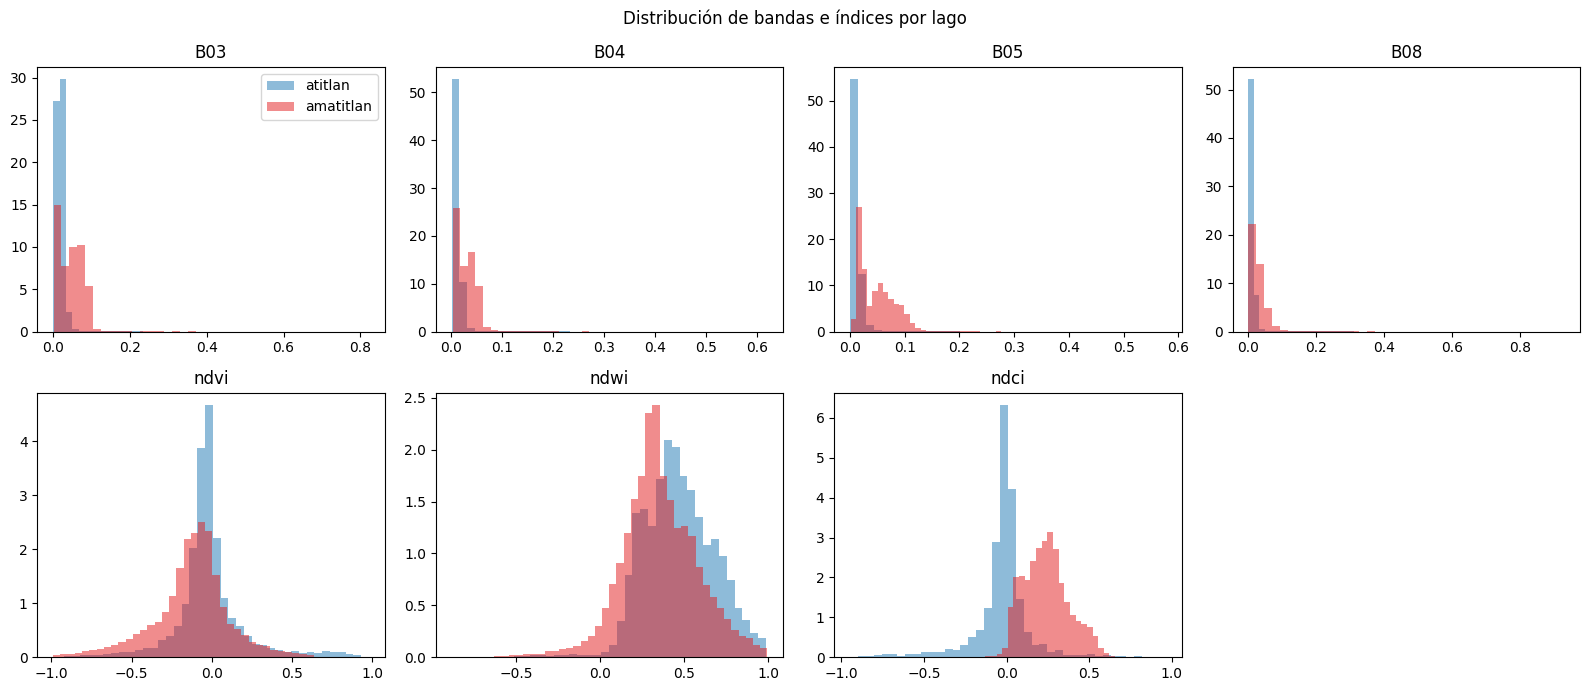

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), ["B03", "B04", "B05", "B08", "ndvi", "ndwi", "ndci"]):
    for clave, color in [("atitlan", "#1f78b4"), ("amatitlan", "#e31a1c")]:
        ax.hist(datos[datos["lago"] == clave][col], bins=40, alpha=0.5,
                color=color, label=clave, density=True)
    ax.set_title(col)
axes.ravel()[-1].axis("off")
axes.ravel()[0].legend()
fig.suptitle("Distribución de bandas e índices por lago")
fig.tight_layout()
plt.show()

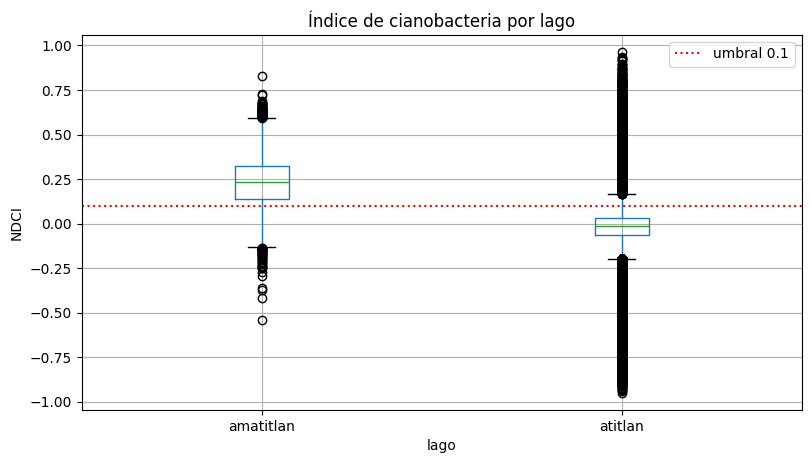

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
datos.boxplot(column="ndci", by="lago", ax=ax)
ax.axhline(UMBRAL_CIANO_ALTO, color="red", ls=":", label=f"umbral {UMBRAL_CIANO_ALTO}")
ax.set_title("Índice de cianobacteria por lago")
ax.set_ylabel("NDCI")
ax.legend()
plt.suptitle("")
plt.show()

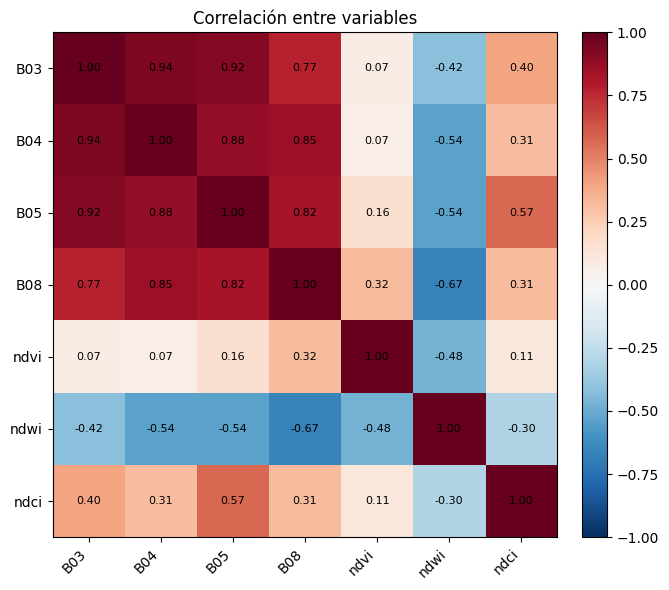

In [9]:
cols = ["B03", "B04", "B05", "B08", "ndvi", "ndwi", "ndci"]
corr = datos[cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)), cols, rotation=45, ha="right")
ax.set_yticks(range(len(cols)), cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlación entre variables")
fig.tight_layout()
plt.show()

La exploración confirma lo que ya veíamos en la Parte 1. El índice de
cianobacteria es mucho más alto en Amatitlán que en Atitlán, y sus
distribuciones apenas se solapan, lo que anticipa que la variable respuesta
estará muy asociada al lago. Entre las variables espectrales, el NDCI se
relaciona de forma positiva con el NDVI y negativa con el NDWI, y las bandas
del rojo y del borde rojo comparten bastante información entre sí.

### 1.6 Decisiones de preparación y limpieza

Tomamos varias decisiones para que el conjunto sea representativo y manejable.
Muestreamos hasta cuatro mil píxeles de agua por escena con una semilla fija, de
modo que el resultado sea reproducible y que ambos lagos aporten la misma
cantidad de observaciones por fecha pese a que Atitlán es mucho más grande que
Amatitlán. Convertimos las bandas a reflectancia dividiendo entre diez mil, que
es la escala nativa de Sentinel-2, sin que eso afecte a los índices porque son
cocientes. Conservamos las coordenadas en metros y en grados para poder
reconstruir mapas y armar bloques espaciales más adelante. Finalmente dejamos
fuera del conjunto los píxeles de tierra, de nube, de sombra y sin datos, así
como el píxel de una escena de Atitlán con un bloque grande de datos faltantes
que ya habíamos detectado en la Parte 1.

## Ejercicio 2. Construcción de la variable respuesta

### 2.1 Variable respuesta binaria

Construimos una variable respuesta binaria a partir del índice de cianobacteria.
Marcamos con uno los píxeles con alta presencia de cianobacteria y con cero los
de ausencia o baja presencia. Como punto de corte usamos el mismo umbral de la
Parte 1, y dejamos la justificación formal de ese valor con base en bibliografía
científica para el inciso 2.2, que corresponde a la otra parte del grupo. Al
final guardamos el conjunto completo con la etiqueta para que el resto de los
ejercicios parta de la misma base.

In [10]:
datos["alta_cianobacteria"] = (datos["ndci"] > UMBRAL_CIANO_ALTO).astype(int)

print("distribución de la variable respuesta:")
print(datos["alta_cianobacteria"].value_counts())
print("\nproporción de clase alta:", round(datos["alta_cianobacteria"].mean(), 3))
datos[["lago", "fecha", "ndci", "alta_cianobacteria"]].head()

distribución de la variable respuesta:
alta_cianobacteria
0    47338
1    40662
Name: count, dtype: int64

proporción de clase alta: 0.462


,lago,fecha,ndci,alta_cianobacteria
0,atitlan,2025-01-18,-0.636364,0
1,atitlan,2025-01-18,0.837838,1
2,atitlan,2025-01-18,-0.500000,0
3,atitlan,2025-01-18,-0.454545,0
4,atitlan,2025-01-18,0.166667,1


In [11]:
# guardamos el conjunto para que la parte de 2.2 en adelante use la misma base
destino = DATA_PROC / "dataset_ml.csv"
datos.to_csv(destino, index=False)
print("conjunto guardado en", destino.relative_to(ROOT), "con", len(datos), "observaciones")

conjunto guardado en data/processed/dataset_ml.csv con 88000 observaciones
